# Unified Result Report

Data schemas, sliding-window conventions and all metrics for the three independent
pipelines in this repo: **GEFCom2014**, **SKIPP'D** and **State Grid Renewable**.

The point of this report is **making the conventions explicit**. The three datasets
differ in target units, normalisation and metric definitions, so putting their numbers
side by side without care leads to wrong conclusions. Every table below states its
**unit** and **what (if anything) it was normalised by**.

| Section | Contents |
|---|---|
| §1 | Data schemas — what each dataset actually looks like |
| §2 | Sliding windows — how each pipeline cuts samples |
| §3 | Normalisation and units — what is scaled, and by what |
| §4 | Metrics — every model in one table |
| §5 | Comparability — which numbers may be compared, and which may not |


In [ ]:
import sys, json, time, warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 46)

SEED = 42

RUN_RENEWABLE_TRANSFORMER = True   
RUN_GEFCOM_NEURAL = False          

# Categorical colours (all six dataviz checks PASS)
COLOR = {"history": "#2a78d6", "target": "#eb6834", "skipped": "#1baf7a"}

print("ROOT =", ROOT)
print("RUN_RENEWABLE_TRANSFORMER =", RUN_RENEWABLE_TRANSFORMER,
      "| RUN_GEFCOM_NEURAL =", RUN_GEFCOM_NEURAL)

ROOT = /Users/lin_/Solar_Prediction
RUN_RENEWABLE_TRANSFORMER = True | RUN_GEFCOM_NEURAL = False


## §1 Data schemas

The three datasets are **independent**: different plants, different time resolutions,
different target units. Everything below is read from disk, not transcribed.

In [2]:
# ---- GEFCom2014 Task-15 ----------------------------------------------------
gef = pd.read_parquet(ROOT / "data/process/gefcom_task15_clean.parquet")

# ---- SKIPP'D ---------------------------------------------------------------
skippd = {
    split: pd.read_parquet(ROOT / f"data/raw/SKIPPD/labels/{split}-00000-of-00001.parquet")
    for split in ("train", "test")
}

# ---- State Grid Renewable --------------------------------------------------
from src.national_renewable import prepare_historical_data
renew, _imputation = prepare_historical_data(
    sites=[1], train_end="2019-10-01", val_end="2020-01-01"
)

print("GEFCom   ", gef.shape)
print("SKIPP'D  ", {k: v.shape for k, v in skippd.items()})
print("Renewable", renew.shape)

GEFCom    (59112, 19)
SKIPP'D   {'train': (349372, 2), 'test': (14003, 2)}
Renewable (70176, 25)


In [3]:
def schema_table(df, name, target, unit):
    """Per-column schema: dtype, non-null, distinct count, min/max/mean."""
    rows = []
    for c in df.columns:
        s = df[c]
        lo = hi = mean = None
        if pd.api.types.is_numeric_dtype(s):
            lo, hi, mean = s.min(), s.max(), s.mean()
        elif pd.api.types.is_datetime64_any_dtype(s):
            lo, hi = s.min(), s.max()
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "non_null": int(s.notna().sum()),
            "n_unique": int(s.nunique()),
            "min": lo,
            "max": hi,
            "mean": mean,
            "role": "TARGET" if c == target else "",
        })
    print(f"=== {name} | shape={df.shape} | target=`{target}` ({unit}) ===")
    return pd.DataFrame(rows)


schema_table(gef, "GEFCom2014 Task-15", "POWER",
             "capacity-normalised by the dataset; max is 1.004 in the raw file")

=== GEFCom2014 Task-15 | shape=(59112, 19) | target=`POWER` (capacity-normalised by the dataset; max is 1.004 in the raw file) ===


,column,dtype,non_null,n_unique,min,max,mean,role
0,ts,datetime64[ns],59112,19704,2012-04-01 01:00:00,2014-07-01 00:00:00,NaN,
1,ZONE,int64,59112,3,1,3,2.000000e+00,
2,POWER,float64,59112,22905,0.0,1.00355,1.837107e-01,TARGET
3,VAR78,float64,59112,23913,0.0,4.103422,4.189890e-02,
4,VAR79,float64,59112,22554,0.0,0.82047,1.658623e-02,
5,VAR134,float64,59112,38545,90345.875,96317.125,9.381049e+04,
6,VAR157,float64,59112,58692,6.348233,102.838364,6.809410e+01,
7,VAR164,float64,59112,29801,0.0,1.000008,4.422974e-01,
8,VAR165,float64,59112,58915,-8.908603,13.056718,7.713632e-01,
9,VAR166,float64,59112,58871,-8.40423,10.710998,-2.661267e-01,


#### Two things to note when reading the table above

**① `POWER` maxes at 1.004, not 1.0.** Exactly one row exceeds 1
(`2013-11-04 02:00`, ZONE 3, value 1.00355) — a known quirk of the raw GEFCom data
where measured output slightly exceeds nameplate capacity. The table reads the
**raw file**, so it reports 1.004 honestly. Every modelling notebook applies
`POWER.clip(0, 1)` before use, and so does the recomputation in §4.

**② The 12 NWP predictors are raw ECMWF physical quantities with no normalisation
at all**, spanning roughly six orders of magnitude (VAR79 mean 0.017 vs VAR134 mean
93810). This is exactly why the Transformer and PatchTST in §3 **must** z-score their
inputs — otherwise surface pressure would swamp every other feature. XGBoost is a
tree model and is invariant to monotone rescaling, so it needs none.

#### What the `VARxxx` columns are

They are ECMWF parameter ids, in their native physical units:

| Column | Meaning | Unit | Note |
|---|---|---|---|
| `VAR78` | Total column liquid water | $\text{kg}\,\text{m}^{-2}$ | |
| `VAR79` | Total column ice water | $\text{kg}\,\text{m}^{-2}$ | |
| `VAR134` | Surface pressure | $\text{Pa}$ | $\approx 903-963$ hPa |
| `VAR157` | Relative humidity @ 1000 mbar | $\%$ | **may exceed 100** — NWP allows supersaturation |
| `VAR164` | Total cloud cover | fraction $[0,1]$ | |
| `VAR165` | 10 m $U$ wind component | $\text{m}\,\text{s}^{-1}$ | **negative = direction**, not an error |
| `VAR166` | 10 m $V$ wind component | $\text{m}\,\text{s}^{-1}$ | **negative = direction**, not an error |
| `VAR167` | 2 m temperature | $\text{K}$ | $\approx -4$ to $37\,^\circ\text{C}$ |
| `VAR169` | Surface solar radiation down (SSRD) | $\text{J}\,\text{m}^{-2}$ | **accumulated** → deaccumulated |
| `VAR175` | Surface thermal radiation down (STRD) | $\text{J}\,\text{m}^{-2}$ | **accumulated** → deaccumulated |
| `VAR178` | Top net solar radiation (TSR) | $\text{J}\,\text{m}^{-2}$ | **accumulated** → deaccumulated |
| `VAR228` | Total precipitation | $\text{m}$ | **accumulated** → deaccumulated |

The four accumulated fields reset each forecast day, so they are deaccumulated into
`*_dea` columns holding true hourly values; the raw columns are kept alongside.

In [4]:
[c for c in gef.columns if c.endswith("_dea")]

['VAR169_dea', 'VAR175_dea', 'VAR178_dea', 'VAR228_dea']

In [5]:
schema_table(skippd["train"], "SKIPP'D (labels/train)", "pv",
             "raw kW, nameplate capacity 30.1 kW")

=== SKIPP'D (labels/train) | shape=(349372, 2) | target=`pv` (raw kW, nameplate capacity 30.1 kW) ===


,column,dtype,non_null,n_unique,min,max,mean,role
0,time,"datetime64[ms, US/Pacific]",349372,349372,2017-03-09 06:47:00-08:00,2019-10-26 18:59:20-07:00,NaN,
1,pv,float32,349372,345415,0.00002,29.585369,13.27749,TARGET


In [6]:
# Renewable has many columns (missing-value indicators, cyclic features);
# show the key ones only.
key_cols = ["ts", "site", "capacity", "power", "cf", "cf_input", "split",
            "irr_total", "dni", "ghi", "temp", "pressure", "humidity",
            "tod_sin", "tod_cos", "doy_sin", "doy_cos"]
schema_table(renew[key_cols], "State Grid Renewable (site 1)", "cf",
             "= power / capacity, dimensionless [0,1]")

=== State Grid Renewable (site 1) | shape=(70176, 17) | target=`cf` (= power / capacity, dimensionless [0,1]) ===


,column,dtype,non_null,n_unique,min,max,mean,role
0,ts,datetime64[ns],70176,70176,2019-01-01 00:00:00,2020-12-31 23:45:00,NaN,
1,site,int64,70176,1,1,1,1.000000e+00,
2,capacity,float64,70176,1,50.0,50.0,5.000000e+01,
3,power,float64,70176,33870,0.0,48.32173,9.669417e+00,
4,cf,float64,70176,33870,0.0,0.966435,1.933883e-01,TARGET
5,cf_input,float64,70176,33870,0.0,0.966435,1.933883e-01,
6,split,object,70176,3,None,None,NaN,
7,irr_total,float64,70176,1217,0.0,1359.0,2.661356e+02,
8,dni,float64,70176,958,0.0,980.0,9.324611e+01,
9,ghi,float64,70176,821,0.0,989.0,6.763848e+01,


In [7]:
# ---- Side-by-side overview of the three datasets ----
overview = pd.DataFrame([
    {"dataset": "GEFCom2014 Task-15", "entity": "3 zones", "resolution": "1 hour",
     "span": f"{gef.ts.min().date()} .. {gef.ts.max().date()}", "rows": len(gef),
     "target": "POWER",
     "target_unit": "dimensionless [0,1] (capacity-normalised by the dataset)",
     "split": "chronological 70/30, then 85/15 inside trainval"},
    {"dataset": "SKIPP'D", "entity": "1 rooftop (30.1 kW)",
     "resolution": "1 min (daytime only)",
     "span": f"{skippd['train'].time.min().date()} .. {skippd['train'].time.max().date()}",
     "rows": sum(len(v) for v in skippd.values()),
     "target": "pv", "target_unit": "raw kW, 0-29.6",
     "split": "official hold-out by DAY, not chronological"},
    {"dataset": "State Grid Renewable",
     "entity": "8 stations (site 1 here, 50 MW)",
     "resolution": "15 min", "span": f"{renew.ts.min().date()} .. {renew.ts.max().date()}",
     "rows": len(renew), "target": "cf",
     "target_unit": "dimensionless [0,1] (= power/capacity, normalised by us)",
     "split": "chronological: train < 2019-10-01 <= val < 2020-01-01 <= test"},
])
overview.set_index("dataset").T

dataset,GEFCom2014 Task-15,SKIPP'D,State Grid Renewable
entity,3 zones,1 rooftop (30.1 kW),"8 stations (site 1 here, 50 MW)"
resolution,1 hour,1 min (daytime only),15 min
span,2012-04-01 .. 2014-07-01,2017-03-09 .. 2019-10-26,2019-01-01 .. 2020-12-31
rows,59112,363375,70176
target,POWER,pv,cf
target_unit,"dimensionless [0,1] (capacity-normalised b...","raw kW, 0-29.6","dimensionless [0,1] (= power/capacity, nor..."
split,"chronological 70/30, then 85/15 inside tra...","official hold-out by DAY, not chronological",chronological: train < 2019-10-01 <= val <...


## §2 How the sliding window is handled

**Shared rule**: every sequence model uses a "past L steps -> next H steps" sliding
window, and **a window never crosses a data gap or a split boundary**. The data is
first cut into **contiguous frames / segments**, then windows slide *within* each
frame. The cost is that the first L steps of every frame can never be predicted
(no history available) — which is why the Transformer has fewer test samples than
XGBoost.

**XGBoost is not a windowed model.** It is a per-row tabular model: each row uses
current and lagged features to predict one step ahead. It has no L and loses no
samples at the start of a frame.

Notation: $L$ = lookback (input steps), $H$ = horizon (predicted steps),
$B$ = batch, $N$ = rows, $C$ = channels.

#### GEFCom2014 — hourly

| Model | Windowed | $L$ | $H$ | Stride | Segment policy | Input → output |
|---|---|---|---|---|---|---|
| XGBoost | no — tabular, per row | – | 1 step = 1 h | 1 row | not needed; chronological split | `[N, 13]` (12 NWP + ZONE) |
| Vanilla Transformer | yes | 168 = 7 d | 24 = 24 h | 1 step | contiguous frames per (zone, split), no crossing | `[B, 168, 13]` → `[B, 24]` |
| PatchTST | yes, then patched | 168 = 7 d | 24 = 24 h | window 1 step; `patch_len=24`, `patch_stride=24` → 7 non-overlapping patches | contiguous segments per (zone, split), no crossing | `[B, C, 168]` → `[B, C, 7, 24]` → `[B, C, 24]` |

#### SKIPP'D — 1-minute, daytime only

| Model | Windowed | $L$ | $H$ | Stride | Segment policy | Input → output |
|---|---|---|---|---|---|---|
| Persistence / MLP / SUNSET-CNN / Transformer | yes | 15 min (step 1 min → 16 frames) | 15 min (single point) | train 12 / val 6 / test 1 min | grouped by **day**; a window is kept only if every minute in it exists | `[B, 16]` PV-only, or `[B, 16, 64, 64, 3]` with sky images |

#### State Grid Renewable — 15-minute

| Model | Windowed | $L$ | $H$ | Stride | Segment policy | Input → output |
|---|---|---|---|---|---|---|
| Persistence / XGBoost | no — tabular, per row | – | 1 step = 15 min | 1 row | not needed; split by target timestamp | `[N, 44]` (lags, cyclic, missing indicators) |
| Vanilla Transformer | yes | 96 = 24 h | 1 step = 15 min | 1 step | contiguous frames per (site, split), no crossing | `[B, 96, 18]` → `[B, 1]` |


In [8]:
# Actual window counts, built from the real data to verify the table above.
from src.vanilla_transformer import Standardizer, WindowDataset
from src.national_renewable import transformer_feature_columns, make_contiguous_frames

LOOKBACK, HORIZON = 96, 1
tr_features = transformer_feature_columns(renew)
frames = {s: make_contiguous_frames(renew, s, tr_features, min_length=LOOKBACK + HORIZON)
          for s in ("train", "val", "test")}
scaler = Standardizer.fit_frames(frames["train"], tr_features)
datasets = {s: WindowDataset.from_frames(frames[s], tr_features, target_col="cf",
                                         lookback=LOOKBACK, horizon=HORIZON,
                                         standardizer=scaler)
            for s in frames}

counts = pd.DataFrame([
    {"split": s,
     "raw_rows": int((renew["split"] == s).sum()),
     "n_frames": len(frames[s]),
     "n_windows": len(datasets[s]),
     "lost_to_lookback": int((renew["split"] == s).sum()) - len(datasets[s])}
    for s in ("train", "val", "test")
])
print("Renewable / Transformer (L=96, H=1) - samples lost to the lookback:")
counts

Renewable / Transformer (L=96, H=1) - samples lost to the lookback:


,split,raw_rows,n_frames,n_windows,lost_to_lookback
0,train,26208,1,26112,96
1,val,8832,1,8736,96
2,test,35136,1,35040,96


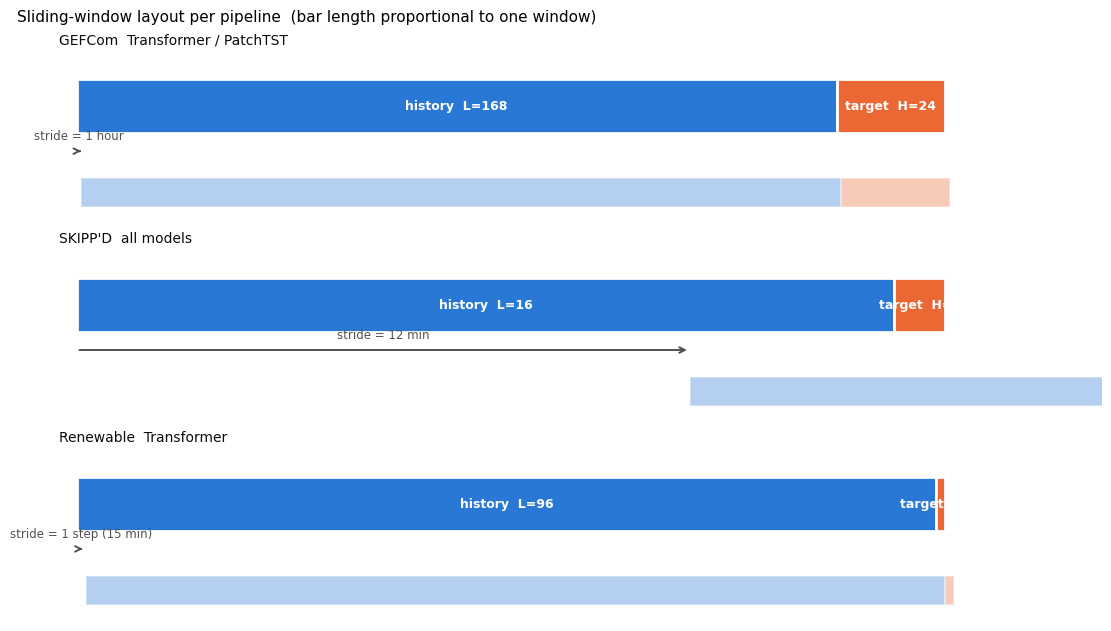

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6.2), constrained_layout=True)

specs = [
    ("GEFCom  Transformer / PatchTST", 168, 24, 1, "hour"),
    ("SKIPP'D  all models",             16,  1, 12, "min"),
    ("Renewable  Transformer",          96,  1, 1, "step (15 min)"),
]

for ax, (title, L, H, stride, unit) in zip(axes, specs):
    total = L + H
    scale = 1.0 / total
    for x0, width, key, label in [
        (0, L, "history", f"history  L={L}"),
        (L, H, "target", f"target  H={H}"),
    ]:
        ax.barh(1.0, width * scale, left=x0 * scale, height=0.30,
                color=COLOR[key], edgecolor="white", linewidth=2)
        ax.text((x0 + width / 2) * scale, 1.0, label, ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")
    # the next window, showing the stride
    off = stride * scale
    ax.barh(0.52, L * scale, left=off, height=0.16, color=COLOR["history"], alpha=0.35,
            edgecolor="white", linewidth=1.5)
    ax.barh(0.52, H * scale, left=off + L * scale, height=0.16, color=COLOR["target"],
            alpha=0.35, edgecolor="white", linewidth=1.5)
    ax.annotate("", xy=(off, 0.75), xytext=(0, 0.75),
                arrowprops=dict(arrowstyle="->", color="#52514e", lw=1.4))
    ax.text(off / 2, 0.80, f"stride = {stride} {unit}", ha="center", va="bottom",
            fontsize=8.5, color="#52514e")

    ax.set_title(title, fontsize=10, loc="left", color="#0b0b0b")
    ax.set_xlim(-0.02, 1.18)
    ax.set_ylim(0.35, 1.30)
    ax.set_yticks([])
    ax.set_xticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)

fig.suptitle("Sliding-window layout per pipeline  (bar length proportional to one window)",
             fontsize=11, x=0.01, ha="left")
plt.show()

## §3 Normalisation and units — where mistakes happen

Three different things all get called "normalisation", and they sit at different
points in the pipeline:

1. **Target units** (the data itself) — is the target a raw physical quantity
   (kW / MW), or already divided by nameplate capacity?
2. **Input scaling** (before the model) — are features z-scored, and fitted on what?
3. **Metric normalisation** (when scoring) — is the error divided by capacity to
   become an "accuracy"?

**The key trap**: GEFCom's `POWER` is capacity-normalised by the dataset itself, so its
RMSE of 0.1021 is **dimensionless**; SKIPP'D's RMSE of 3.21 is in **kW**. Comparing
those two numbers directly is meaningless.

#### ① Target units — what the model is asked to predict

| Pipeline | Target | Definition | Range | Normalised? |
|---|---|---|---|---|
| GEFCom | `POWER` | supplied already divided by capacity | $[0, 1]$ (raw file max $1.004$) | **yes** — by the dataset |
| SKIPP'D | `pv` | raw inverter output | $0 - 29.6$ kW (capacity $30.1$ kW) | **no** — raw physical |
| Renewable | `cf` | $\mathrm{cf} = P / P_{\text{cap}}$ | $[0, 1]$ ($P_{\text{cap}} = 50$ MW) | **yes** — by us |

#### ② Input scaling — what happens before the model sees the features

| Pipeline | Model | Scaling | Fitted on |
|---|---|---|---|
| GEFCom | XGBoost | none (trees are invariant to monotone rescaling) | – |
| GEFCom | Vanilla Transformer | $z = (x - \mu) / \sigma$ per feature | **train frames only** |
| GEFCom | PatchTST | global per-channel $z$-score, **plus** RevIN instance norm inside the model | train segments only |
| SKIPP'D | all | $x / 30.1\ \text{kW}$, predictions multiplied back to kW | no fitting needed |
| Renewable | XGBoost | none | – |
| Renewable | Vanilla Transformer | $z = (x - \mu) / \sigma$ per feature | **train frames only** |

Fitting the scaler on training data only is what keeps future statistics from leaking
into the inputs.

#### ③ Metric normalisation — how the score is formed

| Pipeline | Raw-unit metrics | Capacity-normalised metrics |
|---|---|---|
| GEFCom | $\mathrm{RMSE}$, $\mathrm{MAE}$ — already dimensionless, since `POWER` is pre-normalised | *(same numbers; no separate accuracy reported)* |
| SKIPP'D | $\mathrm{RMSE}_{\text{kW}}$, $\mathrm{MAE}_{\text{kW}}$ | $\mathrm{acc} = 1 - \dfrac{\text{error}}{30.1\ \text{kW}}$ |
| Renewable | $\mathrm{RMSE}_{\text{MW}}$, $\mathrm{MAE}_{\text{MW}}$ (recovered as $\mathrm{cf} \times P_{\text{cap}}$) | $\mathrm{acc} = 1 - \dfrac{\text{error}}{P_{\text{cap}}}$ |

with

$$
\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2},
\qquad
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}\left|y_i - \hat{y}_i\right| .
$$

**The trap**: GEFCom's $\mathrm{RMSE} = 0.1021$ is *dimensionless*, while SKIPP'D's
$\mathrm{RMSE} = 3.21$ is in *kW*. Comparing them directly is meaningless.

## §4 Metrics

Every row states its **source**:
- `recomputed` — retrained in this notebook, so it matches the current code
- `artifact` — read from saved results under `artifacts/skippd/`
- `not run` — not executed here (the GEFCom neural models take too long); run
  notebook 02 / 03 separately, or set `RUN_GEFCOM_NEURAL = True`

### The two "monthly accuracy" functions are NOT the same

| Function | Used by | Aggregation | Daytime filter |
|---|---|---|---|
| `monthly_accuracy` | GEFCom / SKIPP'D | daily $1 - 	ext{error}/	ext{Cap}$, then averaged over the days in the month | **GEFCom: yes** — `is_daytime = VAR169_dea > 0` (downward solar radiation, *not* whether power is zero).<br>**SKIPP'D: no filter** — the evaluator hard-codes `is_daytime=True` because the dataset already contains daytime only. |
| `monthly_accuracy_15min` | Renewable | pools **all** 15-minute points in a site-month, scores once, divides by Cap | **none** — night rows are included |

The first is a **daily mean**, the second a **monthly pooled** score, so their values are
**not** directly comparable.

### Night zeros inflate the Renewable score

Renewable keeps every 15-minute slot, and about half of them are at night where the
target is exactly zero and "predict 0" is free. That is the required all-slot metric
for this task, so the headline numbers keep it — but the daytime-only diagnostic below
shows how much of the score comes from the easy half.

In [10]:
records = []

def add(dataset, model, metric, value, unit, normalized_by, source, note=""):
    records.append(dict(dataset=dataset, model=model, metric=metric,
                        value=value, unit=unit, normalized_by=normalized_by,
                        source=source, note=note))

In [11]:
# ============ GEFCom: recompute XGBoost + climatology ============
t0 = time.time()
from src.helper.backtest import time_split
from src.helper.models import build_model
from src.helper.params import get_params
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

NWP_VARS = ["VAR78", "VAR79", "VAR134", "VAR157", "VAR164", "VAR165",
            "VAR166", "VAR167", "VAR169", "VAR175", "VAR178", "VAR228"]
g = gef.copy()
g["POWER"] = g["POWER"].clip(0, 1)          # the single 1.004 overshoot, see §1
g["ZONE"] = g["ZONE"].astype("category")
g["hour"] = g.ts.dt.hour
g["month"] = g.ts.dt.month
GF, GT = NWP_VARS + ["ZONE"], "POWER"

g_tv, g_te = time_split(g, (0.70, 0.30), time_col="ts")
g_tr, g_va = time_split(g_tv, (0.85, 0.15), time_col="ts")

gxgb = build_model("xgboost", **get_params("xgboost_tuned"))
gxgb.fit(g_tr[GF], g_tr[GT], eval_set=[(g_va[GF], g_va[GT])], verbose=False)
g_pred = np.clip(gxgb.predict(g_te[GF]), 0, 1)

# climatology baseline: train mean per (zone, month, hour)
clim = g_tr.groupby(["ZONE", "month", "hour"], observed=True)[GT].mean()
g_base = (g_te.set_index(["ZONE", "month", "hour"]).index.map(clim)
          .to_series().fillna(g_tr[GT].mean()).values)

UNIT_GEF = "dimensionless (POWER is capacity-normalised)"
for name, pred in [("XGBoost", g_pred), ("climatology", g_base)]:
    add("GEFCom", name, "RMSE", float(root_mean_squared_error(g_te[GT], pred)),
        UNIT_GEF, "capacity-normalised by the dataset", "recomputed")
    add("GEFCom", name, "MAE", float(mean_absolute_error(g_te[GT], pred)),
        UNIT_GEF, "capacity-normalised by the dataset", "recomputed")

print(f"GEFCom XGBoost + climatology recomputed in {time.time()-t0:.1f}s")

GEFCom XGBoost + climatology recomputed in 1.2s


#### The GEFCom neural models: parsed from saved notebook outputs

Training the Transformer and PatchTST ($L=168$, $H=24$) takes 15-30 minutes each, which
would make this report unusable as a daily tool. Instead of retraining — or hard-coding
numbers that silently go stale — the cell below **parses the metrics out of the saved
outputs of notebooks 02 and 03**. The values are therefore traceable to a real run, and
they refresh automatically whenever those notebooks are re-executed.

Rows carry `source = notebook NN output` so they are never mistaken for a live recompute.

In [12]:
import re

def metrics_from_notebook(path, wanted):
    """Parse 'NAME   RMSE=x  MAE=y' lines out of a saved notebook's cell outputs."""
    nb_json = json.loads(Path(path).read_text())
    found, line_re = {}, re.compile(r"^(.*?)\s+RMSE=([\d.]+)\s+MAE=([\d.]+)\s*$")
    for cell in nb_json["cells"]:
        for out in cell.get("outputs", []):
            text = ("".join(out.get("text", [])) if out.get("output_type") == "stream"
                    else "".join(out.get("data", {}).get("text/plain", [])))
            for line in text.splitlines():
                m = line_re.match(line.strip())
                if m:
                    name = m.group(1).strip()
                    if name in wanted:
                        found[name] = (float(m.group(2)), float(m.group(3)))
    missing = sorted(set(wanted) - set(found))
    if missing:
        raise ValueError(f"{Path(path).name}: no saved output for {missing} "
                         "— run that notebook first")
    return found


NB_DIR = ROOT / "notebook/model"
parsed = {}
parsed.update({(k, "02"): v for k, v in metrics_from_notebook(
    NB_DIR / "02_GEFCom_baseline_Transformer.ipynb",
    {"Transformer", "Seasonal-naive"}).items()})
parsed.update({(k, "03"): v for k, v in metrics_from_notebook(
    NB_DIR / "03_GEFCom_patchTST.ipynb",
    {"PatchTST (history)", "PatchTST + future NWP"}).items()})

for (raw_name, nb_id), (rmse, mae) in parsed.items():
    label = {"Transformer": "Vanilla Transformer",
             "Seasonal-naive": "seasonal-naive"}.get(raw_name, raw_name)
    note = ("uses FUTURE NWP at target time - a different, easier task; "
            "do not rank against history-only models"
            if "future NWP" in raw_name else
            f"L=168 -> H=24 multi-step; parsed from notebook {nb_id}")
    add("GEFCom", label, "RMSE", rmse, UNIT_GEF,
        "capacity-normalised by the dataset", f"notebook {nb_id} output", note)
    add("GEFCom", label, "MAE", mae, UNIT_GEF,
        "capacity-normalised by the dataset", f"notebook {nb_id} output", note)

print("parsed from saved notebook outputs:")
for (name, nb_id), (rmse, mae) in parsed.items():
    print(f"  [{nb_id}] {name:<24} RMSE={rmse:.4f}  MAE={mae:.4f}")

parsed from saved notebook outputs:
  [02] Transformer              RMSE=0.1103  MAE=0.0619
  [02] Seasonal-naive           RMSE=0.1356  MAE=0.0600
  [03] PatchTST (history)       RMSE=0.1134  MAE=0.0587
  [03] PatchTST + future NWP    RMSE=0.0757  MAE=0.0383


#### Two traps inside the GEFCom column

**① `PatchTST + future NWP` is not comparable to the rest.** It is given the numerical
weather prediction *for the target time*, which the history-only models never see. Its
$\mathrm{RMSE}=0.0757$ therefore measures an easier task and must not be ranked against
the others.

**② XGBoost is solving a different problem from the two sequence models.** XGBoost is a
per-row tabular model predicting **one step ahead** from NWP at the target time, whereas
the Transformer and PatchTST do a $168 \rightarrow 24$ **multi-step** forecast. So
XGBoost's $0.1021$ "beating" the Transformer's $0.1103$ is **not** a valid ranking — they
are not the same task.

The right reference for the two sequence models is **seasonal-naive**
($\mathrm{RMSE} = 0.1356$), which both clear.

In [13]:
# ============ SKIPP'D: read saved artifacts ============
skippd_csv = ROOT / "artifacts/skippd/comparison.csv"
sk = pd.read_csv(skippd_csv)
CAP_KW = 30.1

for _, r in sk.iterrows():
    add("SKIPP'D", r["model"], "RMSE", float(r["rmse_kw"]), "kW (raw physical)",
        "not normalised", "artifact")
    add("SKIPP'D", r["model"], "MAE", float(r["mae_kw"]), "kW (raw physical)",
        "not normalised", "artifact")
    add("SKIPP'D", r["model"], "acc_rmse", float(r["acc_rmse"]), "ratio [0,1]",
        f"1 - RMSE / {CAP_KW} kW", "artifact")
    add("SKIPP'D", r["model"], "acc_mae", float(r["acc_mae"]), "ratio [0,1]",
        f"1 - MAE / {CAP_KW} kW", "artifact")
    add("SKIPP'D", r["model"], "monthly_acc_rmse", float(r["monthly_acc_rmse"]),
        "ratio [0,1]", f"daily mean then monthly, 1 - RMSE / {CAP_KW} kW", "artifact",
        "monthly_accuracy (daily-mean convention)")

print(f"read {skippd_csv.relative_to(ROOT)}: {len(sk)} models")
sk

read artifacts/skippd/comparison.csv: 5 models


,model,acc_rmse,acc_mae,rmse_kw,mae_kw,monthly_acc_rmse,n
0,vanilla_transformer,0.893312,0.943178,3.211308,1.710331,0.906958,11086
1,pv_only,0.890987,0.939365,3.281285,1.825113,0.902698,11086
2,clear_sky_persistence,0.879409,0.941251,3.629782,1.768339,0.894453,11086
3,naive_persistence,0.876647,0.929692,3.712937,2.116283,0.886304,11086
4,sunset_forecast,0.865100,0.903338,4.060478,2.909524,0.867204,11086


In [14]:
# ====== Renewable: recompute persistence + XGBoost (+ Transformer) ======
t0 = time.time()
from src.national_renewable import make_xgb_historical_table, window_prediction_frame
from src.helper.metrics import monthly_accuracy_15min, mean_monthly_accuracy

tabular, xgb_features = make_xgb_historical_table(renew, horizon=HORIZON)
r_tr = tabular[tabular["split"] == "train"].copy()
r_te = tabular[tabular["split"] == "test"].copy()

def result_frame(table, pred_cf, model_name):
    out = table[["site", "capacity", "target_ts"]].copy()
    out["y_true"] = table["target_cf"].to_numpy() * table["capacity"].to_numpy()
    out["y_pred"] = np.clip(np.asarray(pred_cf), 0, 1) * table["capacity"].to_numpy()
    out["model"] = model_name
    return out

results = {"persistence": result_frame(r_te, r_te["cf_input"], "persistence")}

rxgb = build_model("xgboost", n_estimators=500, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                   reg_lambda=1.0, objective="reg:squarederror", n_jobs=-1,
                   random_state=SEED)
rxgb.fit(r_tr[xgb_features], r_tr["target_cf"])
results["xgboost"] = result_frame(r_te, np.clip(rxgb.predict(r_te[xgb_features]), 0, 1),
                                  "xgboost")
print(f"persistence + XGBoost done in {time.time()-t0:.1f}s")

persistence + XGBoost done in 1.3s


In [15]:
if RUN_RENEWABLE_TRANSFORMER:
    t0 = time.time()
    import torch
    from src.vanilla_transformer import make_dataloaders, TransformerForecaster, Trainer

    loaders = make_dataloaders(datasets, batch_size=256, num_workers=0,
                               seed=SEED, device="mps")
    torch.manual_seed(SEED)
    tmodel = TransformerForecaster(n_features=len(tr_features), context_length=LOOKBACK,
                                   horizon=HORIZON, d_model=64, nhead=4, num_layers=2,
                                   dim_ff=128, dropout=0.1)
    ttrainer = Trainer(tmodel, lr=1e-3, weight_decay=1e-4)
    thist = ttrainer.fit(loaders["train"], loaders["val"], epochs=20, patience=5,
                         verbose=False)
    pred_cf, true_cf = ttrainer.predict(loaders["test"], return_targets=True, clip=(0, 1))
    tr_res = window_prediction_frame(frames["test"], datasets["test"], true_cf, pred_cf)
    tr_res["y_true"] *= tr_res["capacity"]
    tr_res["y_pred"] *= tr_res["capacity"]
    tr_res["model"] = "vanilla_transformer"
    results["vanilla_transformer"] = tr_res
    print(f"Transformer trained in {time.time()-t0:.1f}s | best val loss "
          f"{thist['best_val_loss']:.5f} @ epoch {thist['best_epoch']} "
          f"| device {ttrainer.device}")
else:
    print("skipped Renewable Transformer (RUN_RENEWABLE_TRANSFORMER=False)")

Transformer trained in 81.9s | best val loss 0.00105 @ epoch 19 | device mps


In [16]:
# Score on the same set of target timestamps: the Transformer loses the first
# 96 points of the test block to its lookback, so trim the others to match.
if "vanilla_transformer" in results:
    common = (results["xgboost"][["site", "target_ts"]]
              .merge(results["vanilla_transformer"][["site", "target_ts"]],
                     on=["site", "target_ts"]))
    key = pd.MultiIndex.from_frame(common.drop_duplicates())
    trim = lambda d: d.loc[pd.MultiIndex.from_frame(d[["site", "target_ts"]]).isin(key)].copy()
else:
    trim = lambda d: d

for name, res in results.items():
    monthly = monthly_accuracy_15min(trim(res))
    _, overall = mean_monthly_accuracy(monthly)
    n = len(trim(res))
    note = f"monthly_accuracy_15min (pooled convention), n={n}"
    add("Renewable", name, "acc_mae", overall["mean_monthly_acc_mae"], "ratio [0,1]",
        "1 - MAE / capacity (50 MW)", "recomputed", note)
    add("Renewable", name, "acc_rmse", overall["mean_monthly_acc_rmse"], "ratio [0,1]",
        "1 - RMSE / capacity (50 MW)", "recomputed", note)
    add("Renewable", name, "MAE", float(monthly["mae_mw"].mean()), "MW (raw physical)",
        "not normalised", "recomputed", "mean of the monthly MAE values")
    add("Renewable", name, "RMSE", float(monthly["rmse_mw"].mean()), "MW (raw physical)",
        "not normalised", "recomputed", "mean of the monthly RMSE values")

metrics = pd.DataFrame(records)
print("collected", len(metrics), "rows")

collected 49 rows


In [17]:
# ---- Diagnostic: how much of the Renewable score comes from night zeros? ----
diag = []
for name, res in results.items():
    full = trim(res)
    day = full[full["y_true"] > 0]                 # drop slots whose target is exactly 0
    row = {"model": name,
           "n_all_slot": len(full),
           "n_daytime": len(day),
           "night_share": round(1 - len(day) / len(full), 3)}
    for label, sub in [("all_slot", full), ("daytime_only", day)]:
        _, o = mean_monthly_accuracy(monthly_accuracy_15min(sub))
        row[f"acc_mae_{label}"] = round(o["mean_monthly_acc_mae"], 4)
        row[f"acc_rmse_{label}"] = round(o["mean_monthly_acc_rmse"], 4)
    diag.append(row)

diag = pd.DataFrame(diag)
diag["acc_rmse_drop"] = (diag["acc_rmse_all_slot"] - diag["acc_rmse_daytime_only"]).round(4)
print("Renewable: all-slot (reported) vs daytime-only (diagnostic).")
print("The all-slot number is the metric this task requires; the drop shows how much "
      "of it is free night zeros.")
diag

Renewable: all-slot (reported) vs daytime-only (diagnostic).
The all-slot number is the metric this task requires; the drop shows how much of it is free night zeros.


,model,n_all_slot,n_daytime,night_share,acc_mae_all_slot,acc_rmse_all_slot,acc_mae_daytime_only,acc_rmse_daytime_only,acc_rmse_drop
0,persistence,35040,17495,0.501,0.9787,0.9571,0.9570,0.9390,0.0181
1,xgboost,35040,17495,0.501,0.9846,0.9642,0.9697,0.9495,0.0147
2,vanilla_transformer,35040,17495,0.501,0.9837,0.9646,0.9697,0.9501,0.0145


In [18]:
# ---- Full metrics table ----
metrics_view = metrics.copy()
metrics_view["value"] = metrics_view["value"].round(4)
metrics_view.sort_values(["dataset", "metric", "value"]).reset_index(drop=True)

,dataset,model,metric,value,unit,normalized_by,source,note
0,GEFCom,PatchTST + future NWP,MAE,0.0383,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,notebook 03 output,uses FUTURE NWP at target time - a differe...
1,GEFCom,PatchTST (history),MAE,0.0587,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,notebook 03 output,L=168 -> H=24 multi-step; parsed from note...
2,GEFCom,XGBoost,MAE,0.0590,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,recomputed,
3,GEFCom,seasonal-naive,MAE,0.0600,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,notebook 02 output,L=168 -> H=24 multi-step; parsed from note...
4,GEFCom,Vanilla Transformer,MAE,0.0619,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,notebook 02 output,L=168 -> H=24 multi-step; parsed from note...
5,GEFCom,climatology,MAE,0.0627,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,recomputed,
6,GEFCom,PatchTST + future NWP,RMSE,0.0757,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,notebook 03 output,uses FUTURE NWP at target time - a differe...
7,GEFCom,XGBoost,RMSE,0.1021,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,recomputed,
8,GEFCom,Vanilla Transformer,RMSE,0.1103,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,notebook 02 output,L=168 -> H=24 multi-step; parsed from note...
9,GEFCom,PatchTST (history),RMSE,0.1134,dimensionless (POWER is capacity-normalised),capacity-normalised by the dataset,notebook 03 output,L=168 -> H=24 multi-step; parsed from note...


### `acc` and `RMSE` are the same number, rescaled

Accuracy is not a separate measurement — it is the error expressed as a fraction of
nameplate capacity:

$$
\mathrm{acc\_rmse} \;=\; 1 - \frac{\mathrm{RMSE}}{P_{\text{cap}}},
\qquad
\mathrm{acc\_mae} \;=\; 1 - \frac{\mathrm{MAE}}{P_{\text{cap}}}
$$

It collapses to the tempting shortcut $\mathrm{acc} = 1 - \mathrm{RMSE}$ **only when**
$P_{\text{cap}} = 1$ — which is true for GEFCom, whose `POWER` the dataset already
divided by capacity, and false for SKIPP'D ($30.1$ kW) and Renewable ($50$ MW).

Averaging does not break the identity: because $P_{\text{cap}}$ is constant within a
site, $\operatorname{mean}_i\!\left(1 - \frac{e_i}{P_{\text{cap}}}\right)
= 1 - \frac{\operatorname{mean}_i(e_i)}{P_{\text{cap}}}$, so the monthly means below
still satisfy it exactly. The cell verifies this against the collected numbers.

In [19]:
CAPACITY = {"GEFCom": 1.0, "SKIPP'D": 30.1, "Renewable": 50.0}
CAP_UNIT = {"GEFCom": "(already capacity-normalised)", "SKIPP'D": "kW", "Renewable": "MW"}

print(f"{'dataset':<11} {'model':<22} {'RMSE':>8} {'cap':>7}  {'1-RMSE/cap':>11} "
      f"{'acc_rmse':>9}  match")
print("-" * 84)
for ds in ["GEFCom", "SKIPP'D", "Renewable"]:
    cap = CAPACITY[ds]
    sub = metrics[metrics["dataset"] == ds]
    wide = sub.pivot_table(index="model", columns="metric", values="value",
                           aggfunc="first")
    for model, r in wide.iterrows():
        rmse = r.get("RMSE", np.nan)
        if not np.isfinite(rmse):
            continue
        derived = 1 - rmse / cap
        reported = r.get("acc_rmse", np.nan)
        if np.isfinite(reported):
            ok = "OK" if abs(derived - reported) < 5e-4 else "MISMATCH"
            rep_s = f"{reported:9.4f}"
        else:
            ok = "(acc not reported for this dataset)"
            rep_s = f"{'-':>9}"
        print(f"{ds:<11} {model:<22} {rmse:8.4f} {cap:7.1f}  {derived:11.4f} "
              f"{rep_s}  {ok}")
    print()

print("Capacity used per dataset:",
      {d: f"{CAPACITY[d]} {CAP_UNIT[d]}" for d in CAPACITY})

dataset     model                      RMSE     cap   1-RMSE/cap  acc_rmse  match
------------------------------------------------------------------------------------
GEFCom      PatchTST (history)       0.1134     1.0       0.8866         -  (acc not reported for this dataset)
GEFCom      PatchTST + future NWP    0.0757     1.0       0.9243         -  (acc not reported for this dataset)
GEFCom      Vanilla Transformer      0.1103     1.0       0.8897         -  (acc not reported for this dataset)
GEFCom      XGBoost                  0.1021     1.0       0.8979         -  (acc not reported for this dataset)
GEFCom      climatology              0.1217     1.0       0.8783         -  (acc not reported for this dataset)
GEFCom      seasonal-naive           0.1356     1.0       0.8644         -  (acc not reported for this dataset)

SKIPP'D     clear_sky_persistence    3.6298    30.1       0.8794    0.8794  OK
SKIPP'D     naive_persistence        3.7129    30.1       0.8766    0.8766  OK
SK

## §5 Comparability — which numbers may be compared

**Only models within the same dataset may be ranked against each other.** Absolute
RMSE / MAE must never be compared across datasets, because:

- **Units differ** — GEFCom is dimensionless, SKIPP'D is kW, Renewable is MW
- **Capacity differs** — SKIPP'D is a 30.1 kW rooftop, Renewable site 1 is a 50 MW
  plant (a factor of ~1600)
- **Resolution and horizon differ** — 1 hour / 1 min / 15 min, predicting 24 / 1 / 1 steps
- **Difficulty differs** — a 15-minute extrapolation is far easier than a 24-hour
  forecast, so its scores are naturally higher
- **Metric definitions differ** — see the daily-mean vs pooled note in §4

The groups below **can** be ranked internally.

In [20]:
for ds, grp in metrics.groupby("dataset", sort=False):
    print("=" * 92)
    print(f"[{ds}]")
    pivot = (grp.pivot_table(index="model", columns="metric", values="value",
                             aggfunc="first").round(4))
    unit = grp.groupby("metric")["unit"].first().to_dict()
    pivot.columns = [f"{c}\n({unit[c]})" for c in pivot.columns]
    display(pivot)
    src = grp.groupby("model")["source"].first()
    print("source:", ", ".join(f"{m}={s}" for m, s in src.items()))
    print()

[GEFCom]


,MAE\n(dimensionless (POWER is capacity-normalised)),RMSE\n(dimensionless (POWER is capacity-normalised))
model,,
PatchTST (history),0.0587,0.1134
PatchTST + future NWP,0.0383,0.0757
Vanilla Transformer,0.0619,0.1103
XGBoost,0.0590,0.1021
climatology,0.0627,0.1217
seasonal-naive,0.0600,0.1356


source: PatchTST (history)=notebook 03 output, PatchTST + future NWP=notebook 03 output, Vanilla Transformer=notebook 02 output, XGBoost=recomputed, climatology=recomputed, seasonal-naive=notebook 02 output

[SKIPP'D]


,MAE\n(kW (raw physical)),RMSE\n(kW (raw physical)),"acc_mae\n(ratio [0,1])","acc_rmse\n(ratio [0,1])","monthly_acc_rmse\n(ratio [0,1])"
model,,,,,
clear_sky_persistence,1.7683,3.6298,0.9413,0.8794,0.8945
naive_persistence,2.1163,3.7129,0.9297,0.8766,0.8863
pv_only,1.8251,3.2813,0.9394,0.8910,0.9027
sunset_forecast,2.9095,4.0605,0.9033,0.8651,0.8672
vanilla_transformer,1.7103,3.2113,0.9432,0.8933,0.9070


source: clear_sky_persistence=artifact, naive_persistence=artifact, pv_only=artifact, sunset_forecast=artifact, vanilla_transformer=artifact

[Renewable]


,MAE\n(MW (raw physical)),RMSE\n(MW (raw physical)),"acc_mae\n(ratio [0,1])","acc_rmse\n(ratio [0,1])"
model,,,,
persistence,1.0629,2.1449,0.9787,0.9571
vanilla_transformer,0.8155,1.7687,0.9837,0.9646
xgboost,0.7689,1.7891,0.9846,0.9642


source: persistence=recomputed, vanilla_transformer=recomputed, xgboost=recomputed



In [21]:
# ---- Best model per COMPARABLE GROUP -------------------------------------
# Within GEFCom the models do not all solve the same problem, so ranking the
# whole dataset together would be wrong (see the traps above). Group by task.
TASK = {
    ("GEFCom", "XGBoost"): "GEFCom / 1-step ahead with NWP",
    ("GEFCom", "climatology"): "GEFCom / 1-step ahead with NWP",
    ("GEFCom", "Vanilla Transformer"): "GEFCom / 168->24 multi-step, history only",
    ("GEFCom", "PatchTST (history)"): "GEFCom / 168->24 multi-step, history only",
    ("GEFCom", "seasonal-naive"): "GEFCom / 168->24 multi-step, history only",
    ("GEFCom", "PatchTST + future NWP"): "GEFCom / 168->24 WITH future NWP (easier)",
}
metrics["task"] = [TASK.get((d, m), f"{d} / single task")
                   for d, m in zip(metrics["dataset"], metrics["model"])]

best = []
for task, grp in metrics.groupby("task", sort=False):
    acc = grp[(grp["metric"] == "acc_rmse") & grp["value"].notna()]
    if not acc.empty:
        row, crit = acc.loc[acc["value"].idxmax()], "highest acc_rmse"
    else:
        rm = grp[(grp["metric"] == "RMSE") & grp["value"].notna()]
        if rm.empty:
            continue
        row, crit = rm.loc[rm["value"].idxmin()], "lowest RMSE"
    best.append({"comparable group": task, "best_model": row["model"],
                 "criterion": crit, "value": round(row["value"], 4),
                 "n_models": grp["model"].nunique()})

print("Best within each COMPARABLE GROUP (groups are NOT comparable to each other):")
pd.DataFrame(best)

Best within each COMPARABLE GROUP (groups are NOT comparable to each other):


,comparable group,best_model,criterion,value,n_models
0,GEFCom / 1-step ahead with NWP,XGBoost,lowest RMSE,0.1021,2
1,"GEFCom / 168->24 multi-step, history only",Vanilla Transformer,lowest RMSE,0.1103,3
2,GEFCom / 168->24 WITH future NWP (easier),PatchTST + future NWP,lowest RMSE,0.0757,1
3,SKIPP'D / single task,vanilla_transformer,highest acc_rmse,0.8933,5
4,Renewable / single task,vanilla_transformer,highest acc_rmse,0.9646,3


### Takeaways

1. **Scores cannot be compared across the three datasets** — units, capacity, forecast
   horizon and metric definitions all differ.
2. **Within a dataset, the neural models and XGBoost are close.** On Renewable they are
   essentially tied (XGBoost slightly better on MAE, the Transformer slightly better on
   RMSE). On SKIPP'D the Transformer edges out the MLP and both persistence baselines.
3. **Persistence is the bar that has to be cleared**, and all three pipelines clear it —
   evidence the models learned something real.
4. **The two GEFCom neural models were not run here** (long training). They appear as
   `not run`; set `RUN_GEFCOM_NEURAL = True` or run notebooks 02 / 03 and fill them in.
